In [1]:
import numpy
print(numpy.__file__)
import pandas as pd
import torch
import torch.nn as nn
import sys
import os

from AIedes.models.counter_models import (
    PositiveFeedForwardAbundanceModel,
    PositiveLSTMAbundanceModel,
    PositiveMultiHeadAttentionModel,
    PositiveHurdleModel
)
from AIedes.train.counter_train import train_mosquito_net

from AIedes.data_loader.counter_data_loader import (
    load_and_process_data,
    prepare_data,
)

from AIedes.utils.counter_losses import get_criterion



/home/biazzin/conda-envs/aiedes-env/lib/python3.12/site-packages/numpy/__init__.py


In [2]:
random_state = 3
dropout_rate = 0.2
layers = 2
hidden_size = 64
bs = 64
learning_rate = "5e-05"  # From your data (appears to be consistent)

#input_variables = "t2m_mean_znorm+tp_sum_znorm+d2m_mean_znorm+p1zn+p2zn"
input_variables = "t2m_mean_norm+prev2_weeklyRates_norm+prev_weeklyRates_norm+tp_sum_norm+d2m_mean_norm"
name_file = "modelpositive_ff_lossFrequencyWeightedMSLE_hid64_lay2_do0.2_lr1e-03_bs64_sd14_t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn"
path = "../../data/"
df = pd.read_pickle(path + name_file + "_results.pkl")
model = torch.load(path+name_file + ".pth", map_location=torch.device('cpu'), weights_only=False)

In [3]:

from sklearn.model_selection import train_test_split
import  numpy as np

params = {
    "model_type": df["model_type"][0],  # or any of the allowed models
    "hidden_dim": df["hidden_dim"][0],
    "num_layers": df["num_layers"][0],
    "dropout": df["dropout"][0],
    "num_epochs": df["num_epochs"][0],
    "lr": df["learning_rate"][0],
    "batch_size": int(df["batch_size"][0]),
    "random_state": int(df["random_state"][0]),
    "num_threads": 1,
    #"variables": ["t2m:mean,max:30", "tp:mean,max:30"],
    #"variables":   "t2m_mean_znorm tp_sum_znorm d2m_mean_znorm p1zn p2zn".split(),
    #"variables":   "t2m_mean_znorm tp_sum_znorm p1zn p2zn".split(),
    "variables":   "t2m_mean_znorm d2m_mean_znorm tp_sum_znorm p1zn p2zn".split(),
    "loss_type": df["loss_type"][0],  # or another from the list
    # "nonzero_weight": 3.0,  # Uncomment if used
    "num_heads": 4,
    "folder_res": "./results/",
    "device": "cpu",  # or "cpu"
    "input_file": "../../data/eggs_y_norm_7days.pkl",
    "save_loss_fig": "yes",  # or "no"
    "plot_loss": False,
    "save_interval": 10,
    "bins": [1],  # Or [0, 10, 50, 200] if you want bins
}

climate_tensor, targets, class_labels, variable_info = load_and_process_data(params)

all_idx = np.arange(len(climate_tensor))
train_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.2,
    random_state=params["random_state"],
    stratify=class_labels if class_labels is not None else None,
)

# And later:
data_egg = pd.read_pickle(params["input_file"])  # Or however you got your original dataframe

# To recover rows:
split_status = np.full(len(all_idx), "", dtype=object)
split_status[train_idx] = "train"
split_status[test_idx] = "test"
data_egg["split"] = split_status
# If climate_tensor and targets are numpy arrays, convert each row to torch.tensor
data_egg["input_data"] = [torch.tensor(x, dtype=torch.float32) for x in climate_tensor]
data_egg["target_data"] = [np.array(x, dtype=np.float32)[0] for x in targets]


Normalizing data...
Normalized 34 fields: ['tp_sum', 'u10_min', 'u10_max', 'u10_mean', 'v10_min', 'v10_max', 'v10_mean', 'd2m_min', 'd2m_max', 'd2m_mean', 't2m_min', 't2m_max', 't2m_mean', 'swvl1_min', 'swvl1_max', 'swvl1_mean', 'tp_sum_monthly', 'u10_min_monthly', 'u10_max_monthly', 'u10_mean_monthly', 'v10_min_monthly', 'v10_max_monthly', 'v10_mean_monthly', 'd2m_min_monthly', 'd2m_max_monthly', 'd2m_mean_monthly', 't2m_min_monthly', 't2m_max_monthly', 't2m_mean_monthly', 'swvl1_min_monthly', 'swvl1_max_monthly', 'swvl1_mean_monthly', 'prev1_rates', 'prev2_rates']


In [4]:

params_vectorNet = {
    "model_type": df["model_type"][0],  # or any of the allowed models
    "hidden_dim": df["hidden_dim"][0],
    "num_layers": df["num_layers"][0],
    "dropout": df["dropout"][0],
    "num_epochs": df["num_epochs"][0],
    "lr": df["learning_rate"][0],
    "batch_size": int(df["batch_size"][0]),
    "random_state": int(df["random_state"][0]),
    "num_threads": 1,
    #"variables": ["t2m:mean,max:30", "tp:mean,max:30"],
    #"variables":   "t2m_mean_znorm tp_sum_znorm d2m_mean_znorm p1zn p2zn".split(),
    #"variables":   "t2m_mean_znorm tp_sum_znorm p1zn p2zn".split(),
    "variables":   "t2m_mean_znorm d2m_mean_znorm tp_sum_znorm p1zn p2zn".split(),
    "loss_type": df["loss_type"][0],  # or another from the list
    # "nonzero_weight": 3.0,  # Uncomment if used
    "num_heads": 4,
    "folder_res": "./results/",
    "device": "cpu",  # or "cpu"
    "input_file": "../../data/eggs_y_norm_7days_vectorNet.pkl",
    "save_loss_fig": "yes",  # or "no"
    "plot_loss": False,
    "save_interval": 10,
    "bins": [1],  # Or [0, 10, 50, 200] if you want bins
}

climate_tensor_vectorNet, targets_vectorNet, class_labels_vectorNet, variable_info_vectorNet = load_and_process_data(params_vectorNet)
all_idx_vectorNet = np.arange(len(climate_tensor_vectorNet))
train_idx_vectorNet, test_idx_vectorNet = train_test_split(
    all_idx_vectorNet,
    test_size=0.2,
    random_state=params_vectorNet["random_state"],
    stratify=class_labels_vectorNet if class_labels_vectorNet is not None else None,
)
data_egg_vectorNet = pd.read_pickle(params_vectorNet["input_file"])  # Or however you got your original dataframe
# To recover rows:
split_status_vectorNet = np.full(len(all_idx_vectorNet), "", dtype=object)
split_status_vectorNet[train_idx_vectorNet] = "train"
split_status_vectorNet[test_idx_vectorNet] = "test"
data_egg_vectorNet["split"] = split_status_vectorNet
# If climate_tensor and targets are numpy arrays, convert each row to torch.tensor
data_egg_vectorNet["input_data"] = [torch.tensor(x, dtype=torch.float32) for x in climate_tensor_vectorNet]
data_egg_vectorNet["target_data"] = [np.array(x, dtype=np.float32)[0] for x in targets_vectorNet]


Normalizing data...
Normalized 16 fields: ['tp_sum', 'd2m_min', 'd2m_max', 'd2m_mean', 't2m_min', 't2m_max', 't2m_mean', 'tp_sum_monthly', 'd2m_min_monthly', 'd2m_max_monthly', 'd2m_mean_monthly', 't2m_min_monthly', 't2m_max_monthly', 't2m_mean_monthly', 'prev1_rates', 'prev2_rates']
Skipped 18 fields: ['u10_min (missing)', 'u10_max (missing)', 'u10_mean (missing)', 'v10_min (missing)', 'v10_max (missing)', 'v10_mean (missing)', 'swvl1_min (missing)', 'swvl1_max (missing)', 'swvl1_mean (missing)', 'u10_min_monthly (missing)', 'u10_max_monthly (missing)', 'u10_mean_monthly (missing)', 'v10_min_monthly (missing)', 'v10_max_monthly (missing)', 'v10_mean_monthly (missing)', 'swvl1_min_monthly (missing)', 'swvl1_max_monthly (missing)', 'swvl1_mean_monthly (missing)']


In [5]:
data_egg["class_labels"] = class_labels
data_egg["predictions"] = [model(x.unsqueeze(0)).squeeze(0).detach().numpy()[0] for x in data_egg["input_data"]]
data_egg_vectorNet["class_labels"] = class_labels_vectorNet
data_egg_vectorNet["predictions"] = [model(x.unsqueeze(0)).squeeze(0).detach().numpy()[0] for x in data_egg_vectorNet["input_data"]]

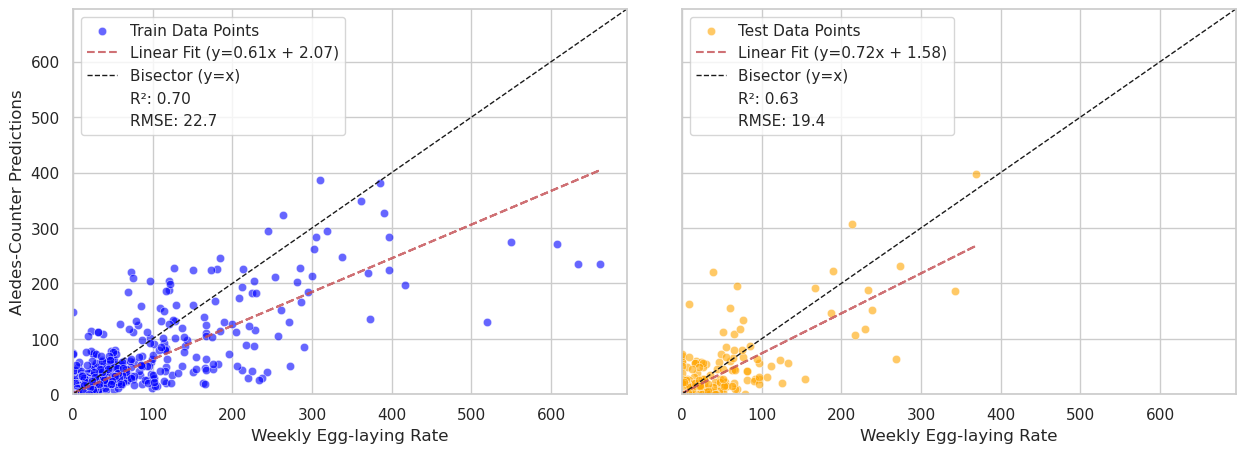

In [6]:
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# scatter plot of targets vs predictions with seaborn
sns.set(style="whitegrid")
fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
data_egg_train = data_egg[data_egg["split"] == "train"]
data_egg_test = data_egg[data_egg["split"] == "test"]

# Train plot
sns.scatterplot(x=data_egg_train["target_data"], y=data_egg_train["predictions"], ax=axs[0], color='blue', alpha=0.6, label='Train Data Points')
r2_train = r2_score(data_egg_train["target_data"], data_egg_train["predictions"])
rmse_train = np.sqrt(mean_squared_error(data_egg_train["target_data"], data_egg_train["predictions"]))
# Add linear fit
z_train = np.polyfit(data_egg_train["target_data"], data_egg_train["predictions"], 1)
p_train = np.poly1d(z_train)
fit_label_train = f'Linear Fit (y={z_train[0]:.2f}x + {z_train[1]:.2f})'
axs[0].plot(data_egg_train["target_data"], p_train(data_egg_train["target_data"]), "r--", alpha=0.8, label=fit_label_train)
#axs[0].set_title('Train')
axs[0].set_xlabel("Weekly Egg-laying Rate")
axs[0].set_ylabel("AIedes-Counter Predictions")

# Test plot
sns.scatterplot(x=data_egg_test["target_data"], y=data_egg_test["predictions"], ax=axs[1], color='orange', alpha=0.6, label='Test Data Points')
r2_test = r2_score(data_egg_test["target_data"], data_egg_test["predictions"])
rmse_test = np.sqrt(mean_squared_error(data_egg_test["target_data"], data_egg_test["predictions"]))
# Add linear fit
z_test = np.polyfit(data_egg_test["target_data"], data_egg_test["predictions"], 1)
p_test = np.poly1d(z_test)
fit_label_test = f'Linear Fit (y={z_test[0]:.2f}x + {z_test[1]:.2f})'
axs[1].plot(data_egg_test["target_data"], p_test(data_egg_test["target_data"]), "r--", alpha=0.8, label=fit_label_test)
#axs[1].set_title('Test')
axs[1].set_xlabel("Weekly Egg-laying Rate")
axs[1].set_ylabel("AIedes-Counter Predictions")

# Determine the overall range for x and y axes
x_max = max(data_egg_train["target_data"].max(), data_egg_test["target_data"].max())
y_max = max(data_egg_train["predictions"].max(), data_egg_test["predictions"].max())
max_limit = max(x_max, y_max) * 1.05 # Use the greater of the two for a square plot, with a 5% buffer

# Set the same limits for both plots
axs[0].set_xlim(0, max_limit)
axs[0].set_ylim(0, max_limit)
axs[1].set_xlim(0, max_limit)
axs[1].set_ylim(0, max_limit)

# Add a diagonal line for reference and legend
axs[0].plot([0, max_limit], [0, max_limit], 'k--', lw=1, label='Bisector (y=x)')
axs[1].plot([0, max_limit], [0, max_limit], 'k--', lw=1, label='Bisector (y=x)')

# Add metrics as legend entries (invisible plots for legend only)
axs[0].plot([], [], ' ', label=f'R²: {r2_train:.2f}')
axs[0].plot([], [], ' ', label=f'RMSE: {rmse_train:.1f}')
axs[1].plot([], [], ' ', label=f'R²: {r2_test:.2f}')
axs[1].plot([], [], ' ', label=f'RMSE: {rmse_test:.1f}')

# Add legends
axs[0].legend(loc='upper left')
axs[1].legend(loc='upper left')
plt.subplots_adjust(wspace=.1)  # Increase horizontal space between plots

#plt.tight_layout()
plt.savefig(f"./R2_scatter_plot.pdf")
plt.show()

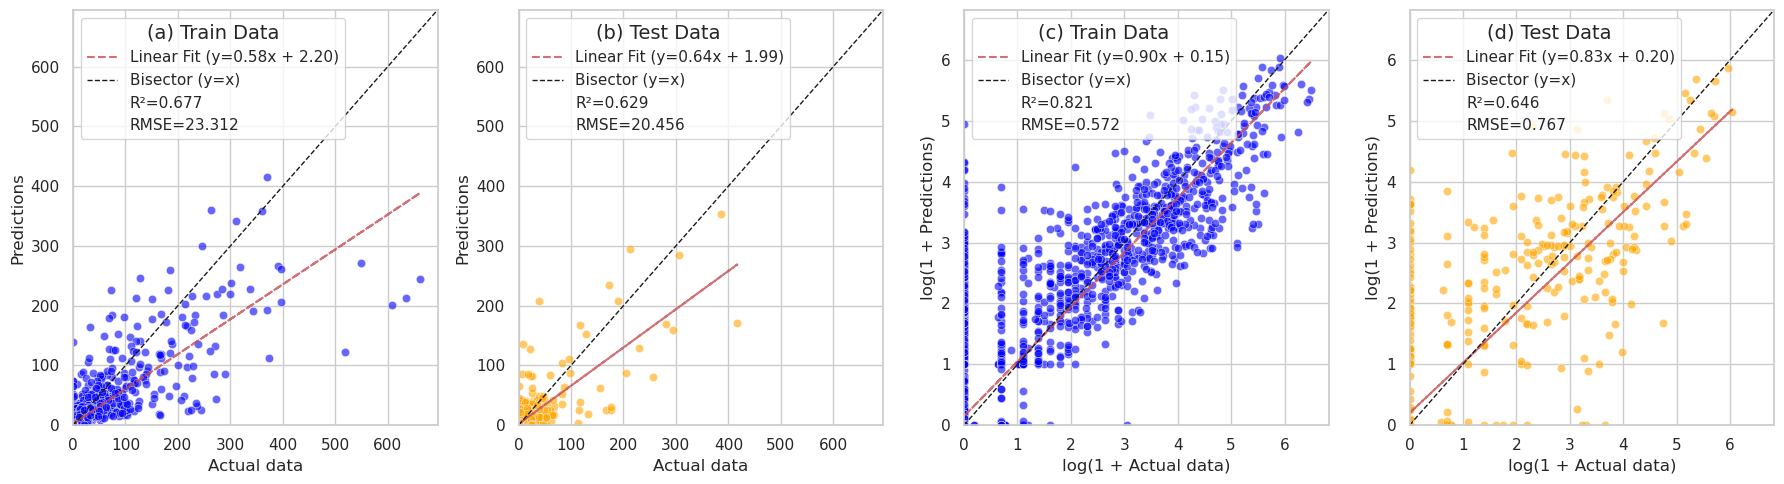

In [7]:
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid")

# Split once
data_egg_train = data_egg[data_egg["split"] == "train"]
data_egg_test  = data_egg[data_egg["split"] == "test"]

# Convenience: safe arrays (drop NaNs if any)
def _xy(df, xcol="target_data", ycol="predictions"):
    x = df[xcol].to_numpy()
    y = df[ycol].to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    return x[m], y[m]

x_tr, y_tr = _xy(data_egg_train)
x_te, y_te = _xy(data_egg_test)

# Shared limits (original scale)
max_limit = 1.05 * max(np.nanmax([x_tr.max() if x_tr.size else 0, x_te.max() if x_te.size else 0]),
                       np.nanmax([y_tr.max() if y_tr.size else 0, y_te.max() if y_te.size else 0]))

# Log-transformed
lx_tr, ly_tr = np.log1p(x_tr), np.log1p(y_tr)
lx_te, ly_te = np.log1p(x_te), np.log1p(y_te)
log_max_limit = 1.05 * max(np.nanmax([lx_tr.max() if lx_tr.size else 0, lx_te.max() if lx_te.size else 0]),
                           np.nanmax([ly_tr.max() if ly_tr.size else 0, ly_te.max() if ly_te.size else 0]))

fig, axs = plt.subplots(1, 4, figsize=(18, 5))

def plot_panel(ax, x, y, color, xlab, ylab, lim, panel_label):
    # scatter
    type_points = "Train" if panel_label in ['(a)', '(c)'] else "Test"
    sns.scatterplot(x=x, y=y, ax=ax, color=color, alpha=0.6)#, label=f'{type_points} points')

    # metrics
    r2   = r2_score(x, y) if x.size and y.size else np.nan
    rmse = np.sqrt(mean_squared_error(x, y)) if x.size and y.size else np.nan

    # linear fit
    if x.size >= 2:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        ax.plot(x, p(x), "r--", alpha=0.8, label=f'Linear Fit (y={z[0]:.2f}x + {z[1]:.2f})')

    # bisector + limits
    ax.plot([0, lim], [0, lim], 'k--', lw=1, label='Bisector (y=x)')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel(xlab); ax.set_ylabel(ylab)

    # dummy legend entries for metrics
    ax.plot([], [], ' ', label=f"R²={r2:.3f}" if np.isfinite(r2) else "R²=NA")
    ax.plot([], [], ' ', label=f"RMSE={rmse:.3f}" if np.isfinite(rmse) else "RMSE=NA")

    # use panel label as legend title (removed title_align parameter)
    ax.legend(loc='upper left', frameon=True, title=panel_label, title_fontsize=14)

# 1) Train (original)
plot_panel(axs[0], x_tr, y_tr, color='blue',
           xlab="Actual data", ylab="Predictions", lim=max_limit, panel_label="(a) Train Data")

# 2) Test (original)
plot_panel(axs[1], x_te, y_te, color='orange',
           xlab="Actual data", ylab="Predictions", lim=max_limit, panel_label="(b) Test Data")

# 3) Train (log)
plot_panel(axs[2], lx_tr, ly_tr, color='blue',
           xlab="log(1 + Actual data)", ylab="log(1 + Predictions)", lim=log_max_limit, panel_label="(c) Train Data")

# 4) Test (log)
plot_panel(axs[3], lx_te, ly_te, color='orange',
           xlab="log(1 + Actual data)", ylab="log(1 + Predictions)", lim=log_max_limit, panel_label="(d) Test Data")

plt.tight_layout()
plt.savefig("./R2_scatter_plot_with_log.pdf")
plt.show()


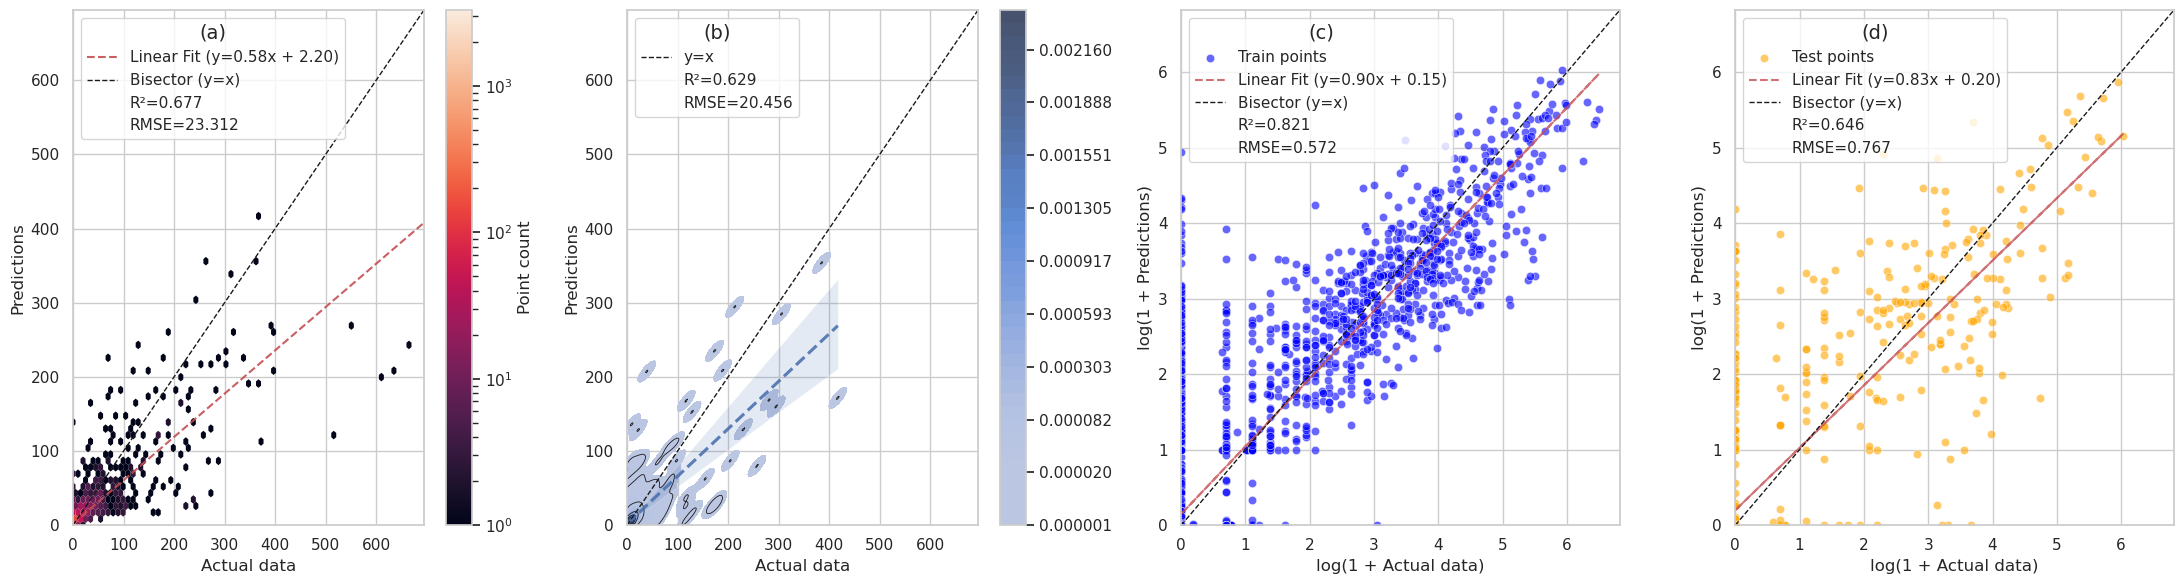

In [8]:
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid")

# Split once
data_egg_train = data_egg[data_egg["split"] == "train"]
data_egg_test  = data_egg[data_egg["split"] == "test"]

# Convenience: safe arrays (drop NaNs if any)
def _xy(df, xcol="target_data", ycol="predictions"):
    x = df[xcol].to_numpy()
    y = df[ycol].to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    return x[m], y[m]

x_tr, y_tr = _xy(data_egg_train)
x_te, y_te = _xy(data_egg_test)

# Shared limits (original scale)
max_limit = 1.05 * max(np.nanmax([x_tr.max() if x_tr.size else 0, x_te.max() if x_te.size else 0]),
                       np.nanmax([y_tr.max() if y_tr.size else 0, y_te.max() if y_te.size else 0]))

# Log-transformed
lx_tr, ly_tr = np.log1p(x_tr), np.log1p(y_tr)
lx_te, ly_te = np.log1p(x_te), np.log1p(y_te)
log_max_limit = 1.05 * max(np.nanmax([lx_tr.max() if lx_tr.size else 0, lx_te.max() if lx_te.size else 0]),
                           np.nanmax([ly_tr.max() if ly_tr.size else 0, ly_te.max() if ly_te.size else 0]))

fig, axs = plt.subplots(1, 4, figsize=(22, 6))

def plot_panel(ax, x, y, color, xlab, ylab, lim, panel_label):
    # scatter
    type_points = "Train" if panel_label in ['(a)', '(c)'] else "Test"
    sns.scatterplot(x=x, y=y, ax=ax, color=color, alpha=0.6, label=f'{type_points} points')

    # metrics
    r2   = r2_score(x, y) if x.size and y.size else np.nan
    rmse = np.sqrt(mean_squared_error(x, y)) if x.size and y.size else np.nan

    # linear fit
    if x.size >= 2:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        ax.plot(x, p(x), "r--", alpha=0.8, label=f'Linear Fit (y={z[0]:.2f}x + {z[1]:.2f})')

    # bisector + limits
    ax.plot([0, lim], [0, lim], 'k--', lw=1, label='Bisector (y=x)')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel(xlab); ax.set_ylabel(ylab)

    # dummy legend entries for metrics
    ax.plot([], [], ' ', label=f"R²={r2:.3f}" if np.isfinite(r2) else "R²=NA")
    ax.plot([], [], ' ', label=f"RMSE={rmse:.3f}" if np.isfinite(rmse) else "RMSE=NA")

    # use panel label as legend title (removed title_align parameter)
    ax.legend(loc='upper left', frameon=True, title=panel_label, title_fontsize=14)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# mode ∈ {"hex", "hist2d", "kde"}
def plot_panel_density(ax, x, y, *, mode="hex", gridsize=70, bins=80,
                       xlab="", ylab="", lim=1.0, panel_label="(a)", color=None):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    # Nothing to plot
    if x.size == 0 or y.size == 0:
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.set_xlabel(xlab); ax.set_ylabel(ylab)
        ax.legend(loc='upper left', frameon=True, title=panel_label, title_fontsize=14)
        return

    # --- DENSITY LAYER ---
    im = None
    if mode == "hex":
        # hexbin with log count normalization
        im = ax.hexbin(
            x, y,
            gridsize=gridsize,
            extent=(0, lim, 0, lim),
            mincnt=1,
            norm=mcolors.LogNorm(),
            linewidths=0,
            rasterized=True
        )
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Point count")
    elif mode == "hist2d":
        h = ax.hist2d(
            x, y,
            bins=bins,
            range=[[0, lim], [0, lim]],
            norm=mcolors.LogNorm()
        )
        cbar = plt.colorbar(h[3], ax=ax)
        cbar.set_label("Point count")
    elif mode == "kde":
        # KDE heatmap + contours; slower for large n
        sns.kdeplot(x=x, y=y, ax=ax, fill=True, thresh=0.02, levels=60, clip=((0, lim), (0, lim)))
        sns.kdeplot(x=x, y=y, ax=ax, fill=False, levels=8, color="k", linewidths=0.6, clip=((0, lim), (0, lim)))
    else:
        raise ValueError("mode must be one of {'hex','hist2d','kde'}")

    # --- METRICS ---
    from sklearn.metrics import r2_score, mean_squared_error
    r2   = r2_score(x, y) if x.size and y.size else np.nan
    rmse = np.sqrt(mean_squared_error(x, y)) if x.size and y.size else np.nan

    # --- LINES (draw AFTER the density so they sit on top) ---
    # Best-fit line
    if x.size >= 2:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        xs = np.array([0.0, lim])
        ax.plot(xs, p(xs), "r--", alpha=0.9, label=f'Linear Fit (y={z[0]:.2f}x + {z[1]:.2f})')
    # Bisector
    ax.plot([0, lim], [0, lim], 'k--', lw=1, label='Bisector (y=x)')

    # Axes, labels, legend
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel(xlab); ax.set_ylabel(ylab)

    # Dummy legend entries for metrics
    ax.plot([], [], ' ', label=f"R²={r2:.3f}" if np.isfinite(r2) else "R²=NA")
    ax.plot([], [], ' ', label=f"RMSE={rmse:.3f}" if np.isfinite(rmse) else "RMSE=NA")
    ax.legend(loc='upper left', frameon=True, title=panel_label, title_fontsize=14)

from matplotlib.colors import LogNorm

from matplotlib.colors import LogNorm

def plot_panel_sb(ax, x, y, *, kind="kde", bins=100, xlab="", ylab="", lim=1.0, panel_label="(a)", color=None):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    if kind == "hist":
        # 2D histogram with log-scaled colorbar
        sns.histplot(
            x=x, y=y, bins=bins,
            binrange=[[0, lim], [0, lim]],
            stat="count", ax=ax, cbar=True,
            log_scale=(False, False),  # keep axes linear
            cbar_kws={"label": "Point count"}
        )
        # then log-scale the colorbar manually
        pcm = ax.collections[0]
        pcm.norm = LogNorm(vmin=1, vmax=pcm.get_array().max())
    elif kind == "kde":
        sns.kdeplot(
            x=x, y=y, ax=ax, fill=True, levels=40, thresh=0.01,
            clip=((0, lim), (0, lim)), cbar=True
        )
        sns.kdeplot(
            x=x, y=y, ax=ax, fill=False, levels=8, color="k", linewidths=0.6,
            clip=((0, lim), (0, lim))
        )
    else:
        raise ValueError("kind must be 'hist' or 'kde'")

    # metrics etc… (same as before)
    from sklearn.metrics import r2_score, mean_squared_error
    r2   = r2_score(x, y) if x.size and y.size else np.nan
    rmse = np.sqrt(mean_squared_error(x, y)) if x.size and y.size else np.nan
    if x.size >= 2:
        sns.regplot(x=x, y=y, scatter=False, ax=ax,
                    line_kws=dict(linestyle="--", alpha=0.9))
    ax.plot([0, lim], [0, lim], 'k--', lw=1, label='y=x')
    ax.plot([], [], ' ', label=f"R²={r2:.3f}" if np.isfinite(r2) else "R²=NA")
    ax.plot([], [], ' ', label=f"RMSE={rmse:.3f}" if np.isfinite(rmse) else "RMSE=NA")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel(xlab); ax.set_ylabel(ylab)
    ax.legend(loc='upper left', frameon=True, title=panel_label, title_fontsize=14)

# 1) Train (original)
plot_panel_density(axs[0], x_tr, y_tr, color='blue',
           xlab="Actual data", ylab="Predictions", lim=max_limit, panel_label="(a)")

# 2) Test (original)
plot_panel_sb(axs[1], x_te, y_te, color='orange',
           xlab="Actual data", ylab="Predictions", lim=max_limit, panel_label="(b)")

# 3) Train (log)
plot_panel(axs[2], lx_tr, ly_tr, color='blue',
           xlab="log(1 + Actual data)", ylab="log(1 + Predictions)", lim=log_max_limit, panel_label="(c)")

# 4) Test (log)
plot_panel(axs[3], lx_te, ly_te, color='orange',
           xlab="log(1 + Actual data)", ylab="log(1 + Predictions)", lim=log_max_limit, panel_label="(d)")

plt.tight_layout()
plt.savefig("./R2_scatter_plot_with_log.pdf")
plt.show()


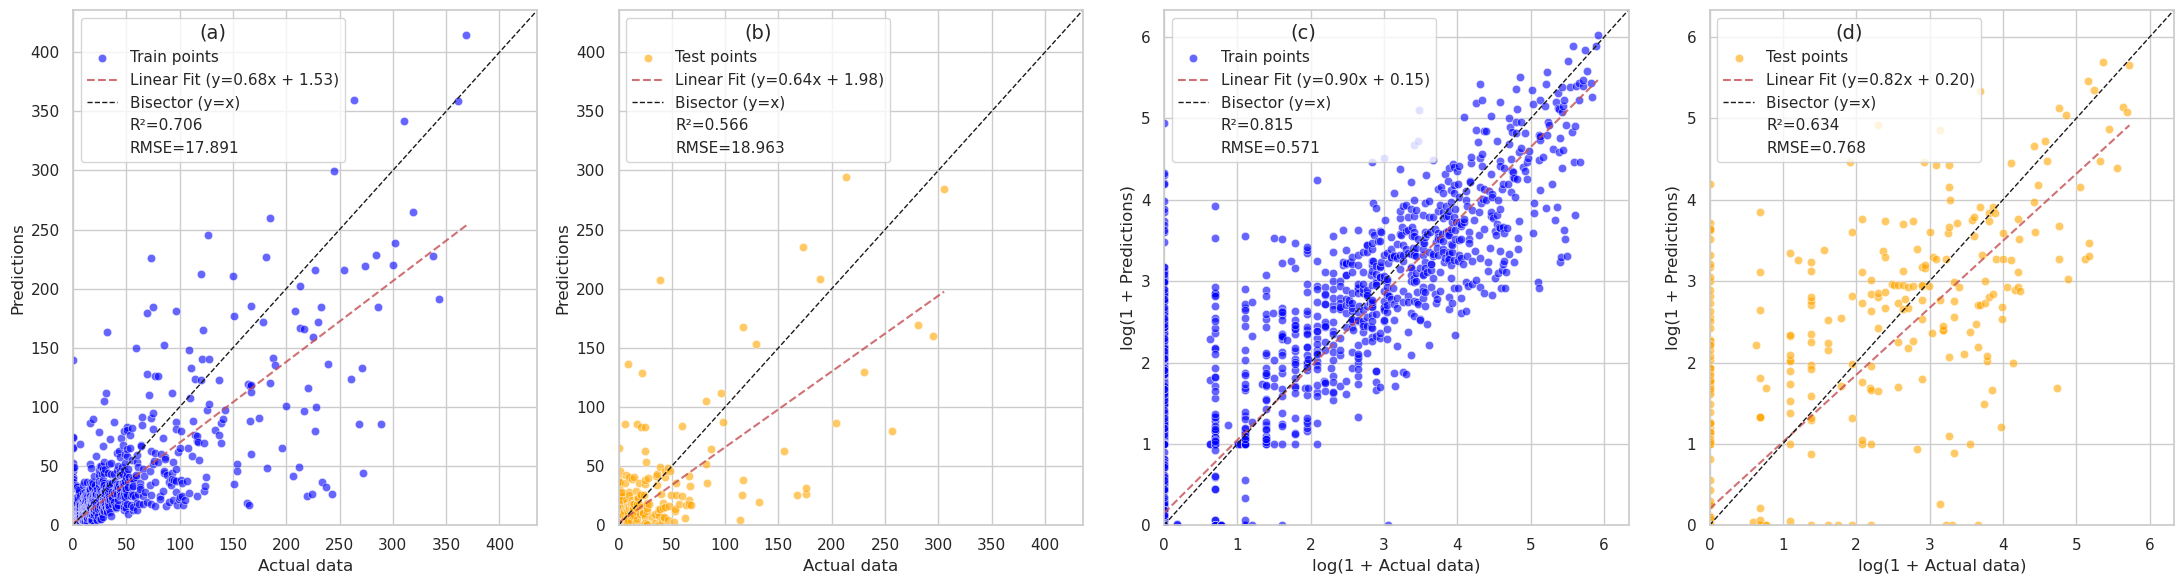

In [11]:
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid")


# Split once
data_egg_train = data_egg[data_egg["split"] == "train"]
data_egg_test  = data_egg[data_egg["split"] == "test"]
# remvoe the 10 higest values from the dataset both in the test and train
data_egg_train = data_egg_train.nsmallest(int(len(data_egg_train)-10), 'target_data')
data_egg_test = data_egg_test.nsmallest(int(len(data_egg_test)-2), 'target_data')

# Convenience: safe arrays (drop NaNs if any)
def _xy(df, xcol="target_data", ycol="predictions"):
    x = df[xcol].to_numpy()
    y = df[ycol].to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    return x[m], y[m]

x_tr, y_tr = _xy(data_egg_train)
x_te, y_te = _xy(data_egg_test)

# Shared limits (original scale)
max_limit = 1.05 * max(np.nanmax([x_tr.max() if x_tr.size else 0, x_te.max() if x_te.size else 0]),
                       np.nanmax([y_tr.max() if y_tr.size else 0, y_te.max() if y_te.size else 0]))

# Log-transformed
lx_tr, ly_tr = np.log1p(x_tr), np.log1p(y_tr)
lx_te, ly_te = np.log1p(x_te), np.log1p(y_te)
log_max_limit = 1.05 * max(np.nanmax([lx_tr.max() if lx_tr.size else 0, lx_te.max() if lx_te.size else 0]),
                           np.nanmax([ly_tr.max() if ly_tr.size else 0, ly_te.max() if ly_te.size else 0]))

fig, axs = plt.subplots(1, 4, figsize=(22, 6))

def plot_panel(ax, x, y, color, xlab, ylab, lim, panel_label):
    # scatter
    type_points = "Train" if panel_label in ['(a)', '(c)'] else "Test"
    sns.scatterplot(x=x, y=y, ax=ax, color=color, alpha=0.6, label=f'{type_points} points')

    # metrics
    r2   = r2_score(x, y) if x.size and y.size else np.nan
    rmse = np.sqrt(mean_squared_error(x, y)) if x.size and y.size else np.nan

    # linear fit
    if x.size >= 2:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        ax.plot(x, p(x), "r--", alpha=0.8, label=f'Linear Fit (y={z[0]:.2f}x + {z[1]:.2f})')

    # bisector + limits
    ax.plot([0, lim], [0, lim], 'k--', lw=1, label='Bisector (y=x)')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel(xlab); ax.set_ylabel(ylab)

    # dummy legend entries for metrics
    ax.plot([], [], ' ', label=f"R²={r2:.3f}" if np.isfinite(r2) else "R²=NA")
    ax.plot([], [], ' ', label=f"RMSE={rmse:.3f}" if np.isfinite(rmse) else "RMSE=NA")

    # use panel label as legend title (removed title_align parameter)
    ax.legend(loc='upper left', frameon=True, title=panel_label, title_fontsize=14)

# 1) Train (original)
plot_panel(axs[0], x_tr, y_tr, color='blue',
           xlab="Actual data", ylab="Predictions", lim=max_limit, panel_label="(a)")

# 2) Test (original)
plot_panel(axs[1], x_te, y_te, color='orange',
           xlab="Actual data", ylab="Predictions", lim=max_limit, panel_label="(b)")

# 3) Train (log)
plot_panel(axs[2], lx_tr, ly_tr, color='blue',
           xlab="log(1 + Actual data)", ylab="log(1 + Predictions)", lim=log_max_limit, panel_label="(c)")

# 4) Test (log)
plot_panel(axs[3], lx_te, ly_te, color='orange',
           xlab="log(1 + Actual data)", ylab="log(1 + Predictions)", lim=log_max_limit, panel_label="(d)")

plt.tight_layout()
plt.savefig("./R2_scatter_plot_with_log.pdf")
plt.show()


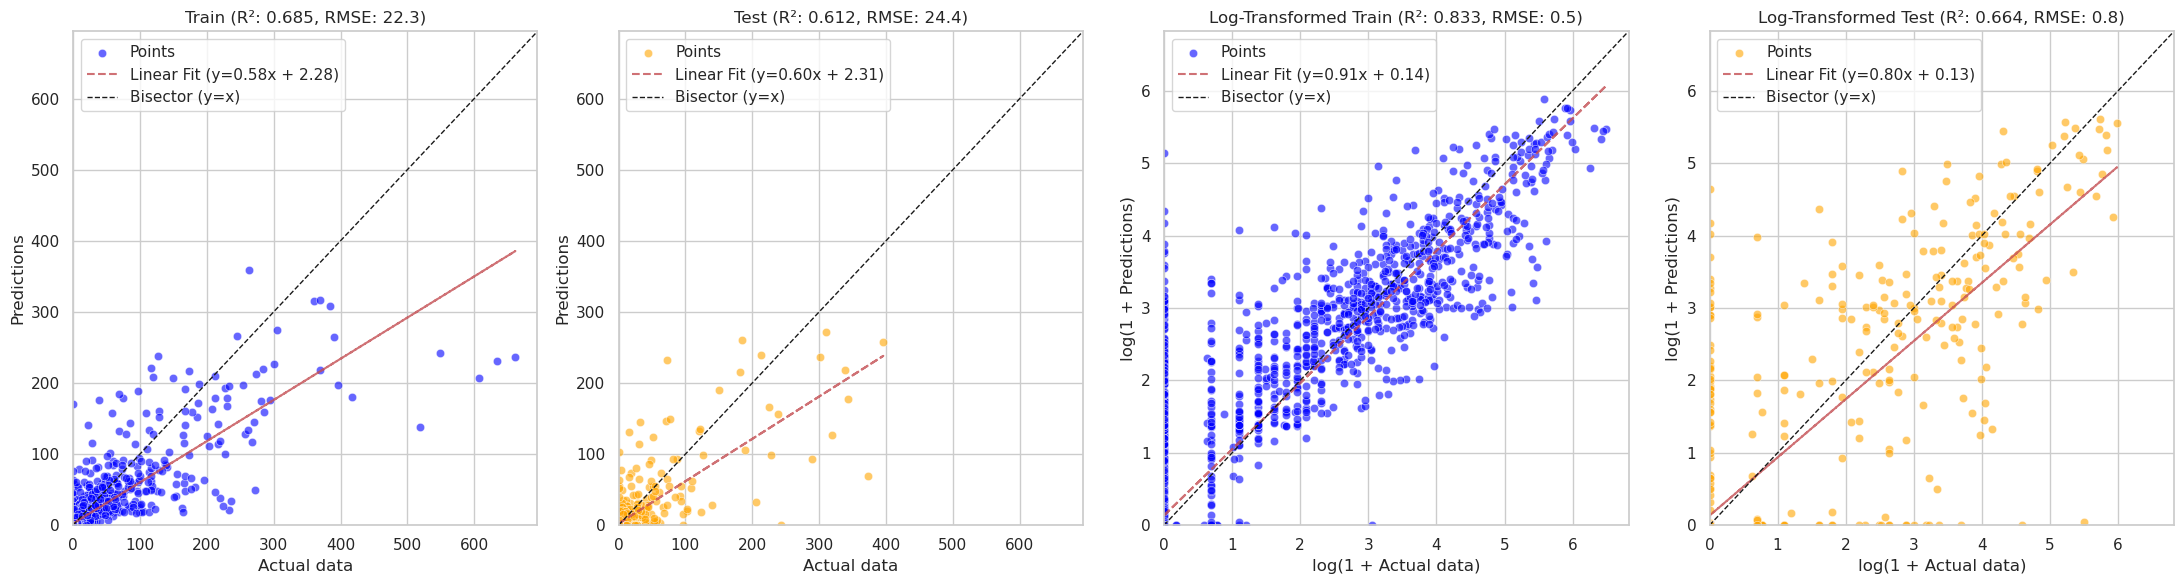

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# scatter plot of targets vs predictions with seaborn
sns.set(style="whitegrid")
fig, axs = plt.subplots(1, 4, figsize=(22, 6))
data_egg_train = data_egg[data_egg["split"] == "train"]
data_egg_test = data_egg[data_egg["split"] == "test"]

# --- Plot 1: Original Data Train ---
sns.scatterplot(x=data_egg_train["target_data"], y=data_egg_train["predictions"], ax=axs[0], color='blue', alpha=0.6, label='Points')
r2_train = r2_score(data_egg_train["target_data"], data_egg_train["predictions"])
rmse_train = np.sqrt(mean_squared_error(data_egg_train["target_data"], data_egg_train["predictions"]))
# Add linear fit
z_train = np.polyfit(data_egg_train["target_data"], data_egg_train["predictions"], 1)
p_train = np.poly1d(z_train)
fit_label_train = f'Linear Fit (y={z_train[0]:.2f}x + {z_train[1]:.2f})'
axs[0].plot(data_egg_train["target_data"], p_train(data_egg_train["target_data"]), "r--", alpha=0.8, label=fit_label_train)
axs[0].set_title(f'Train (R²: {r2_train:.3f}, RMSE: {rmse_train:.1f})')
axs[0].set_xlabel("Actual data")
axs[0].set_ylabel("Predictions")

# --- Plot 2: Original Data Test ---
sns.scatterplot(x=data_egg_test["target_data"], y=data_egg_test["predictions"], ax=axs[1], color='orange', alpha=0.6, label='Points')
r2_test = r2_score(data_egg_test["target_data"], data_egg_test["predictions"])
rmse_test = np.sqrt(mean_squared_error(data_egg_test["target_data"], data_egg_test["predictions"]))
# Add linear fit
z_test = np.polyfit(data_egg_test["target_data"], data_egg_test["predictions"], 1)
p_test = np.poly1d(z_test)
fit_label_test = f'Linear Fit (y={z_test[0]:.2f}x + {z_test[1]:.2f})'
axs[1].plot(data_egg_test["target_data"], p_test(data_egg_test["target_data"]), "r--", alpha=0.8, label=fit_label_test)
axs[1].set_title(f'Test (R²: {r2_test:.3f}, RMSE: {rmse_test:.1f})')
axs[1].set_xlabel("Actual data")
axs[1].set_ylabel("Predictions")

# Determine the overall range for x and y axes for the original data plots
x_max = max(data_egg_train["target_data"].max(), data_egg_test["target_data"].max())
y_max = max(data_egg_train["predictions"].max(), data_egg_test["predictions"].max())
max_limit = max(x_max, y_max) * 1.05 # Use the greater of the two for a square plot, with a 5% buffer

# Set the same limits for the first two plots
for ax in axs[:2]:
    ax.set_xlim(0, max_limit)
    ax.set_ylim(0, max_limit)
    ax.plot([0, max_limit], [0, max_limit], 'k--', lw=1, label='Bisector (y=x)')
    ax.legend(loc='upper left')

# --- Plot 3: Log-transformed Data Train ---
# Prepare log-transformed data
log_target_train = np.log1p(data_egg_train["target_data"])
log_pred_train = np.log1p(data_egg_train["predictions"])
log_target_test = np.log1p(data_egg_test["target_data"])
log_pred_test = np.log1p(data_egg_test["predictions"])

sns.scatterplot(x=log_target_train, y=log_pred_train, ax=axs[2], color='blue', alpha=0.6, label='Points')
r2_log_train = r2_score(log_target_train, log_pred_train)
rmse_log_train = np.sqrt(mean_squared_error(log_target_train, log_pred_train))
# Add linear fit
z_log_train = np.polyfit(log_target_train, log_pred_train, 1)
p_log_train = np.poly1d(z_log_train)
fit_label_log_train = f'Linear Fit (y={z_log_train[0]:.2f}x + {z_log_train[1]:.2f})'
axs[2].plot(log_target_train, p_log_train(log_target_train), "r--", alpha=0.8, label=fit_label_log_train)
axs[2].set_title(f'Log-Transformed Train (R²: {r2_log_train:.3f}, RMSE: {rmse_log_train:.1f})')
axs[2].set_xlabel("log(1 + Actual data)")
axs[2].set_ylabel("log(1 + Predictions)")

# --- Plot 4: Log-transformed Data Test ---
sns.scatterplot(x=log_target_test, y=log_pred_test, ax=axs[3], color='orange', alpha=0.6, label='Points')
r2_log_test = r2_score(log_target_test, log_pred_test)
rmse_log_test = np.sqrt(mean_squared_error(log_target_test, log_pred_test))
# Add linear fit
z_log_test = np.polyfit(log_target_test, log_pred_test, 1)
p_log_test = np.poly1d(z_log_test)
fit_label_log_test = f'Linear Fit (y={z_log_test[0]:.2f}x + {z_log_test[1]:.2f})'
axs[3].plot(log_target_test, p_log_test(log_target_test), "r--", alpha=0.8, label=fit_label_log_test)
axs[3].set_title(f'Log-Transformed Test (R²: {r2_log_test:.3f}, RMSE: {rmse_log_test:.1f})')
axs[3].set_xlabel("log(1 + Actual data)")
axs[3].set_ylabel("log(1 + Predictions)")

# Determine the overall range for x and y axes for the log-transformed plots
log_x_max = max(log_target_train.max(), log_target_test.max())
log_y_max = max(log_pred_train.max(), log_pred_test.max())
log_max_limit = max(log_x_max, log_y_max) * 1.05

# Set the same limits for the last two plots
for ax in axs[2:]:
    ax.set_xlim(0, log_max_limit)
    ax.set_ylim(0, log_max_limit)
    ax.plot([0, log_max_limit], [0, log_max_limit], 'k--', lw=1, label='Bisector (y=x)')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(f"./R2_scatter_plot_with_log.pdf")
plt.show()


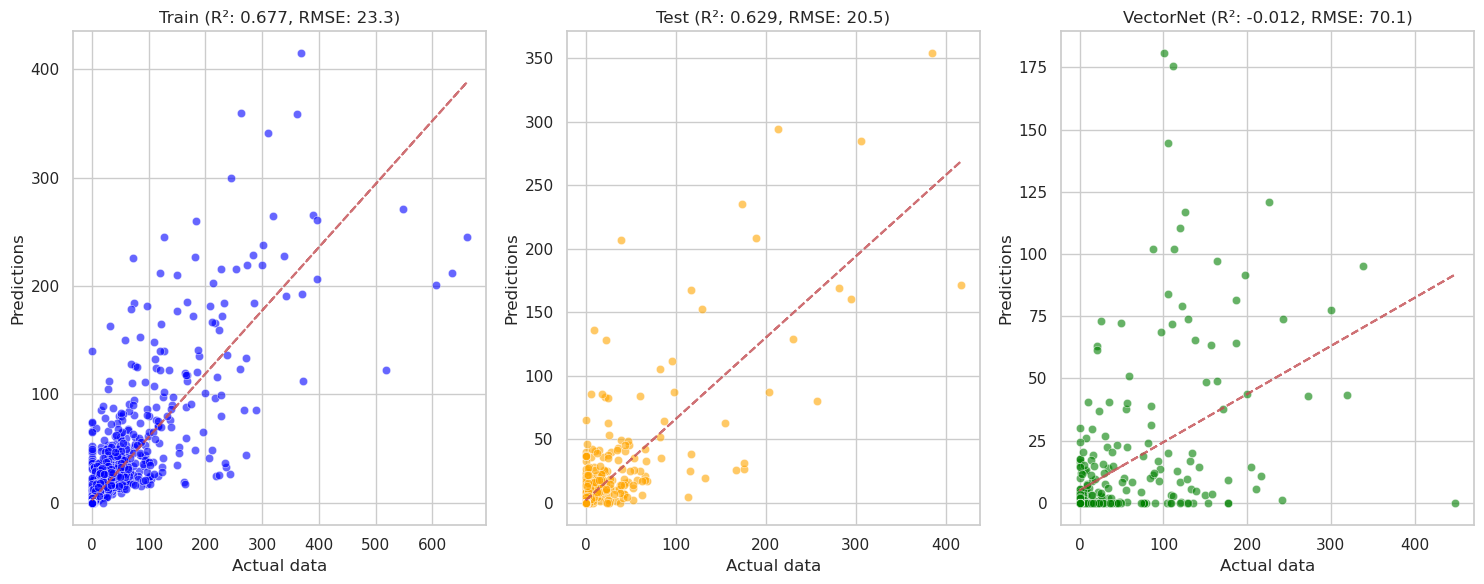

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
# scatter plot of targets vs predictions with seaborn
sns.set(style="whitegrid")
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
data_egg_train = data_egg[data_egg["split"] == "train"]
data_egg_test = data_egg[data_egg["split"] == "test"]

# Train plot
sns.scatterplot(x=data_egg_train["target_data"], y=data_egg_train["predictions"], ax=axs[0], color='blue', alpha=0.6)
r2_train = r2_score(data_egg_train["target_data"], data_egg_train["predictions"])
rmse_train = np.sqrt(mean_squared_error(data_egg_train["target_data"], data_egg_train["predictions"]))
# Add linear fit
z_train = np.polyfit(data_egg_train["target_data"], data_egg_train["predictions"], 1)
p_train = np.poly1d(z_train)
axs[0].plot(data_egg_train["target_data"], p_train(data_egg_train["target_data"]), "r--", alpha=0.8)
axs[0].set_title(f'Train (R²: {r2_train:.3f}, RMSE: {rmse_train:.1f})')
axs[0].set_xlabel("Actual data")
axs[0].set_ylabel("Predictions")

# Test plot
sns.scatterplot(x=data_egg_test["target_data"], y=data_egg_test["predictions"], ax=axs[1], color='orange', alpha=0.6)
r2_test = r2_score(data_egg_test["target_data"], data_egg_test["predictions"])
rmse_test = np.sqrt(mean_squared_error(data_egg_test["target_data"], data_egg_test["predictions"]))
# Add linear fit
z_test = np.polyfit(data_egg_test["target_data"], data_egg_test["predictions"], 1)
p_test = np.poly1d(z_test)
axs[1].plot(data_egg_test["target_data"], p_test(data_egg_test["target_data"]), "r--", alpha=0.8)
axs[1].set_title(f'Test (R²: {r2_test:.3f}, RMSE: {rmse_test:.1f})')
axs[1].set_xlabel("Actual data")
axs[1].set_ylabel("Predictions")

# VectorNet plot
sns.scatterplot(x=data_egg_vectorNet["target_data"], y=data_egg_vectorNet["predictions"], ax=axs[2], color='green', alpha=0.6)
r2_vectornet = r2_score(data_egg_vectorNet["target_data"], data_egg_vectorNet["predictions"])
rmse_vectornet = np.sqrt(mean_squared_error(data_egg_vectorNet["target_data"], data_egg_vectorNet["predictions"]))
# Add linear fit
z_vectornet = np.polyfit(data_egg_vectorNet["target_data"], data_egg_vectorNet["predictions"], 1)
p_vectornet = np.poly1d(z_vectornet)
axs[2].plot(data_egg_vectorNet["target_data"], p_vectornet(data_egg_vectorNet["target_data"]), "r--", alpha=0.8)
axs[2].set_title(f'VectorNet (R²: {r2_vectornet:.3f}, RMSE: {rmse_vectornet:.1f})')
axs[2].set_xlabel("Actual data")
axs[2].set_ylabel("Predictions")

plt.tight_layout()
plt.show()